# Bivariate Normal Distribution on Old Faithful Data
This notebook demonstrates how to compute and visualize the bivariate normal probability density for the Old Faithful geyser dataset.

## Step 1: Load and Parse Data
We fetch the Old Faithful geyser dataset from a public repository, then parse the CSV to extract eruption duration and waiting time values.

In [8]:
import urllib.request
import csv
import math
import matplotlib.pyplot as plt

# 1. Fetch the data from a public repository
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
response = urllib.request.urlopen(url)
lines = [l.decode('utf-8') for l in response.readlines()]

x_duration = []
y_waiting = []

# 2. Parse the CSV (skipping the header row)
reader = csv.reader(lines)
next(reader)  # Skip header: duration, waiting, kind
for row in reader:
    try:
        x_duration.append(float(row[0]))
        y_waiting.append(float(row[1]))
    except ValueError:
        continue # Skip any incomplete rows

print(f"Loaded {len(x_duration)} data points.")

Loaded 272 data points.


## Step 2: Calculate Statistics
We define functions to compute the mean, standard deviation, and correlation for the dataset. These are used to parameterize the bivariate normal distribution.

In [9]:
def get_mean(data):
    return sum(data) / len(data)

def get_stdev(data, mean):
    # Using n-1 for sample standard deviation
    variance = sum((val - mean)**2 for val in data) / (len(data) - 1)
    return math.sqrt(variance)

def get_correlation(x_data, y_data, x_mean, y_mean, x_std, y_std):
    n = len(x_data)
    # Calculate sample covariance
    covariance = sum((x_data[i] - x_mean) * (y_data[i] - y_mean) for i in range(n)) / (n - 1)
    # Correlation is covariance divided by the product of standard deviations
    return covariance / (x_std * y_std)

# Calculate parameters
mu_x = get_mean(x_duration)
mu_y = get_mean(y_waiting)
sig_x = get_stdev(x_duration, mu_x)
sig_y = get_stdev(y_waiting, mu_y)
rho = get_correlation(x_duration, y_waiting, mu_x, mu_y, sig_x, sig_y)

print(f"Duration (X): Mean = {mu_x:.2f}, StdDev = {sig_x:.2f}")
print(f"Waiting (Y): Mean = {mu_y:.2f}, StdDev = {sig_y:.2f}")
print(f"Correlation (rho) = {rho:.4f}")

Duration (X): Mean = 3.49, StdDev = 1.14
Waiting (Y): Mean = 70.90, StdDev = 13.59
Correlation (rho) = 0.9008


## Step 3: Implement the PDF Function
We implement a Python function to compute the bivariate normal PDF for any given pair of values, using the parameters calculated earlier.

## Bivariate Normal PDF Formula

$$f(x,y) = \frac{1}{2\pi\sigma_x\sigma_y\sqrt{1-\rho^2}} \exp\left( -\frac{1}{2(1-\rho^2)} \left[ \frac{(x-\mu_x)^2}{\sigma_x^2} + \frac{(y-\mu_y)^2}{\sigma_y^2} - \frac{2\rho(x-\mu_x)(y-\mu_y)}{\sigma_x\sigma_y} \right] \right)$$

This is the mathematical formula for the bivariate normal probability density function, which models the joint distribution of two variables.

In [10]:
def bivariate_normal_pdf(x, y, mu_x, mu_y, sig_x, sig_y, rho):
    """Calculates the Bivariate Normal PDF for a given (x, y) point."""

    # 1. Calculate the normalization constant
    constant = 1.0 / (2 * math.pi * sig_x * sig_y * math.sqrt(1 - rho**2))

    # 2. Calculate the z-terms inside the bracket
    z_x = (x - mu_x) / sig_x
    z_y = (y - mu_y) / sig_y

    bracket_term = (z_x**2) + (z_y**2) - (2 * rho * z_x * z_y)

    # 3. Combine into the final exponent
    exponent = -bracket_term / (2 * (1 - rho**2))

    # 4. Return the final density value
    return constant * math.exp(exponent)

## Step 4: Calculate Densities
We use the PDF function to compute the probability density for each data point in the dataset. The first few results are printed for inspection.

In [11]:
# Calculate the PDF density for every point in our dataset
densities = []
for i in range(len(x_duration)):
    density = bivariate_normal_pdf(
        x_duration[i], y_waiting[i],
        mu_x, mu_y, sig_x, sig_y, rho
    )
    densities.append(density)

# Print first 5 densities and their corresponding points
for i in range(5):
    print(f"Point ({x_duration[i]:.2f}, {y_waiting[i]:.2f}): Density = {densities[i]:.6f}")

Point (3.60, 79.00): Density = 0.011875
Point (1.80, 54.00): Density = 0.007751
Point (3.33, 74.00): Density = 0.016901
Point (2.28, 62.00): Density = 0.010719
Point (4.53, 85.00): Density = 0.013779


## Step 6: Visualize the Results
We plot the data points, coloring each by its computed probability density. This helps visualize how well the bivariate normal model fits the joint distribution of eruption duration and waiting time.

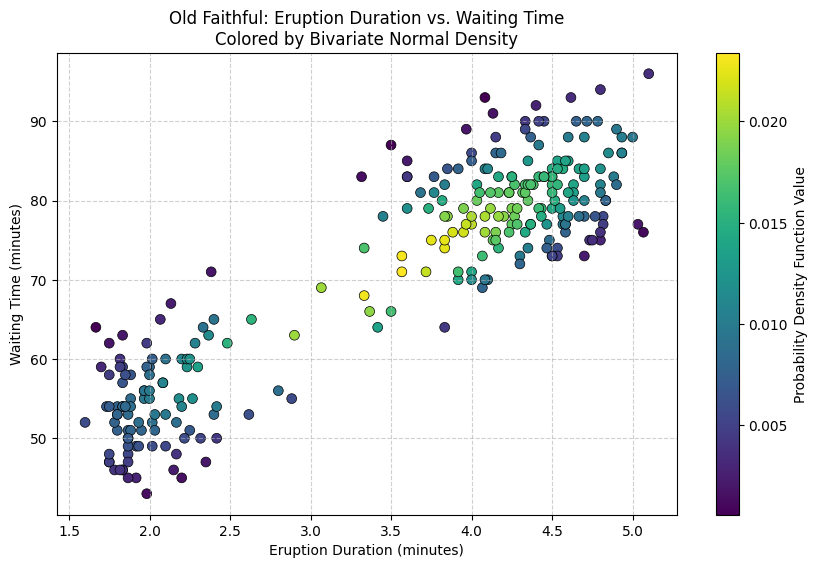

In [12]:
# --- Visualization ---
plt.figure(figsize=(10, 6))

# We use the calculated 'densities' to color the points.
# Darker/warmer colors mean higher probability density.
scatter = plt.scatter(x_duration, y_waiting, c=densities, cmap='viridis', s=50, edgecolor='black', linewidth=0.5)

plt.colorbar(scatter, label='Probability Density Function Value')
plt.title('Old Faithful: Eruption Duration vs. Waiting Time\nColored by Bivariate Normal Density')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Contour Plot of Bivariate PDF
Contours represent regions of equal probability density, providing a clear view of the distribution's shape and correlation between the two variables.

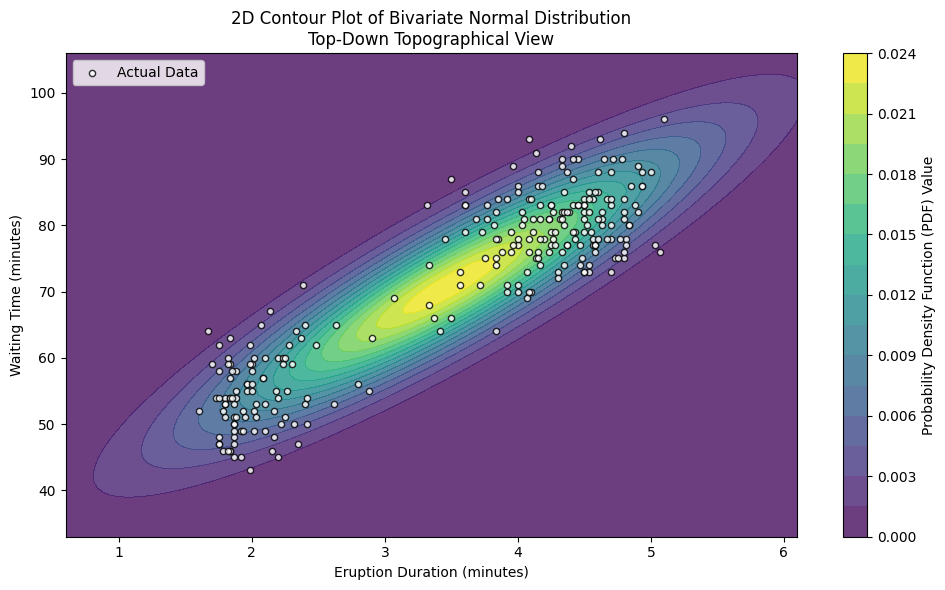

In [13]:
import numpy as np

# Create a coordinate grid that spans our minimum and maximum values
x_grid = np.linspace(min(x_duration) - 1, max(x_duration) + 1, 100)
y_grid = np.linspace(min(y_waiting) - 10, max(y_waiting) + 10, 100)
X, Y = np.meshgrid(x_grid, y_grid)

# Initialize an empty array to hold our calculated Z (probability density) values
Z = np.zeros_like(X)

# Calculate the PDF for every single intersection point on that grid 
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = bivariate_normal_pdf(
            X[i, j], Y[i, j], 
            mu_x, mu_y, sig_x, sig_y, rho
        )

# --- Visualization: Contour Plot ---
plt.figure(figsize=(10, 6))

# Draw the filled contour lines
contour = plt.contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Probability Density Function (PDF) Value')

# Overlay the actual dataset points
plt.scatter(x_duration, y_waiting, color='white', edgecolor='black', 
            s=20, alpha=0.8, label='Actual Data')

plt.title('2D Contour Plot of Bivariate Normal Distribution\nTop-Down Topographical View')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3D Surface Plot of Bivariate PDF
We visualize the bivariate normal probability density function as a 3D surface. The X and Y axes represent the two variables, while the Z axis shows the computed density values, helping to illustrate the joint distribution.

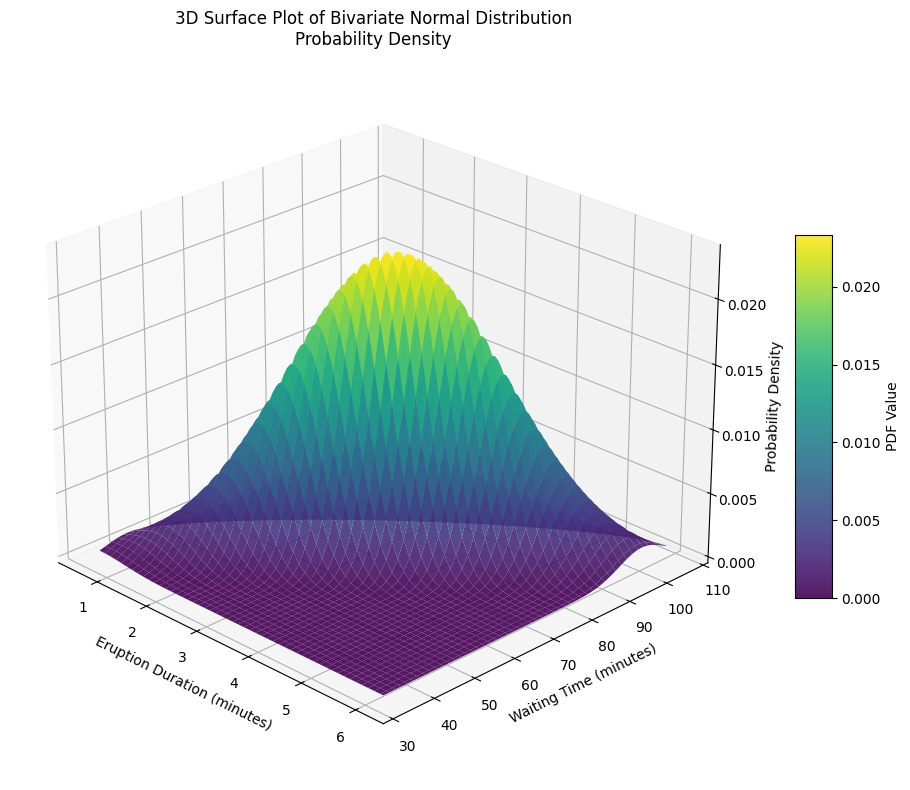

In [14]:
# --- Visualization: 3D Surface Plot ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the calculated Z grid as a 3D surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

# Add a color bar
fig.colorbar(surf, label='PDF Value', shrink=0.5, aspect=10)

ax.set_title('3D Surface Plot of Bivariate Normal Distribution\nProbability Density')
ax.set_xlabel('Eruption Duration (minutes)')
ax.set_ylabel('Waiting Time (minutes)')
ax.set_zlabel('Probability Density')

# Rotate the plot slightly for a better viewing angle
ax.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()